# 区域卷积神经网络（R-CNN）系列
:label:`sec_rcnn`

除了 :numref:`sec_ssd`中描述的单发多框检测之外，
区域卷积神经网络（region-based CNN或regions with CNN features，R-CNN） :cite:`Girshick.Donahue.Darrell.ea.2014`也是将深度模型应用于目标检测的开创性工作之一。
本节将介绍R-CNN及其一系列改进方法：快速的R-CNN（Fast R-CNN） :cite:`Girshick.2015`、更快的R-CNN（Faster R-CNN） :cite:`Ren.He.Girshick.ea.2015`和掩码R-CNN（Mask R-CNN） :cite:`He.Gkioxari.Dollar.ea.2017`。
限于篇幅，我们只着重介绍这些模型的设计思路。

## R-CNN

*R-CNN*首先从输入图像中选取若干（例如2000个）*提议区域*（如锚框也是一种选取方法），并标注它们的类别和边界框（如偏移量）。 :cite:`Girshick.Donahue.Darrell.ea.2014`然后，用卷积神经网络对每个提议区域进行前向传播以抽取其特征。
接下来，我们用每个提议区域的特征来预测类别和边界框。

![R-CNN模型](../img/r-cnn.svg)
:label:`fig_r-cnn`

 :numref:`fig_r-cnn`展示了R-CNN模型。具体来说，R-CNN包括以下四个步骤：

1. 对输入图像使用*选择性搜索*来选取多个高质量的提议区域 :cite:`Uijlings.Van-De-Sande.Gevers.ea.2013`。这些提议区域通常是在多个尺度下选取的，并具有不同的形状和大小。每个提议区域都将被标注类别和真实边界框；
1. 选择一个预训练的卷积神经网络，并将其在输出层之前截断。将每个提议区域变形为网络需要的输入尺寸，并通过前向传播输出抽取的提议区域特征；
1. 将每个提议区域的特征连同其标注的类别作为一个样本。训练多个支持向量机对目标分类，其中每个支持向量机用来判断样本是否属于某一个类别；
1. 将每个提议区域的特征连同其标注的边界框作为一个样本，训练线性回归模型来预测真实边界框。

尽管R-CNN模型通过预训练的卷积神经网络有效地抽取了图像特征，但它的速度很慢。
想象一下，我们可能从一张图像中选出上千个提议区域，这需要上千次的卷积神经网络的前向传播来执行目标检测。
这种庞大的计算量使得R-CNN在现实世界中难以被广泛应用。

## Fast R-CNN

R-CNN的主要性能瓶颈在于，对每个提议区域，卷积神经网络的前向传播是独立的，而没有共享计算。
由于这些区域通常有重叠，独立的特征抽取会导致重复的计算。
*Fast R-CNN* :cite:`Girshick.2015`对R-CNN的主要改进之一，是仅在整张图象上执行卷积神经网络的前向传播。

![Fast R-CNN模型](../img/fast-rcnn.svg)
:label:`fig_fast_r-cnn`

 :numref:`fig_fast_r-cnn`中描述了Fast R-CNN模型。它的主要计算如下：

1. 与R-CNN相比，Fast R-CNN用来提取特征的卷积神经网络的输入是整个图像，而不是各个提议区域。此外，这个网络通常会参与训练。设输入为一张图像，将卷积神经网络的输出的形状记为$1 \times c \times h_1  \times w_1$；
1. 假设选择性搜索生成了$n$个提议区域。这些形状各异的提议区域在卷积神经网络的输出上分别标出了形状各异的兴趣区域。然后，这些感兴趣的区域需要进一步抽取出形状相同的特征（比如指定高度$h_2$和宽度$w_2$），以便于连结后输出。为了实现这一目标，Fast R-CNN引入了*兴趣区域汇聚层*（RoI pooling）：将卷积神经网络的输出和提议区域作为输入，输出连结后的各个提议区域抽取的特征，形状为$n \times c \times h_2 \times w_2$；
1. 通过全连接层将输出形状变换为$n \times d$，其中超参数$d$取决于模型设计；
1. 预测$n$个提议区域中每个区域的类别和边界框。更具体地说，在预测类别和边界框时，将全连接层的输出分别转换为形状为$n \times q$（$q$是类别的数量）的输出和形状为$n \times 4$的输出。其中预测类别时使用softmax回归。

在Fast R-CNN中提出的兴趣区域汇聚层与 :numref:`sec_pooling`中介绍的汇聚层有所不同。在汇聚层中，我们通过设置汇聚窗口、填充和步幅的大小来间接控制输出形状。而兴趣区域汇聚层对每个区域的输出形状是可以直接指定的。

例如，指定每个区域输出的高和宽分别为$h_2$和$w_2$。
对于任何形状为$h \times w$的兴趣区域窗口，该窗口将被划分为$h_2 \times w_2$子窗口网格，其中每个子窗口的大小约为$(h/h_2) \times (w/w_2)$。
在实践中，任何子窗口的高度和宽度都应向上取整，其中的最大元素作为该子窗口的输出。
因此，兴趣区域汇聚层可从形状各异的兴趣区域中均抽取出形状相同的特征。

作为说明性示例， :numref:`fig_roi`中提到，在$4 \times 4$的输入中，我们选取了左上角$3\times 3$的兴趣区域。
对于该兴趣区域，我们通过$2\times 2$的兴趣区域汇聚层得到一个$2\times 2$的输出。
请注意，四个划分后的子窗口中分别含有元素0、1、4、5（5最大）；2、6（6最大）；8、9（9最大）；以及10。

![一个 $2\times 2$ 的兴趣区域汇聚层](../img/roi.svg)
:label:`fig_roi`

下面，我们演示了兴趣区域汇聚层的计算方法。
假设卷积神经网络抽取的特征`X`的高度和宽度都是4，且只有单通道。


Proposal（提议区域/候选框）在 R-CNN 系列的不同演进阶段，其生成方法、输入和输出截然不同。主要分为两大流派：**传统图像算法（R-CNN / Fast R-CNN）** 与 **深度神经网络（Faster R-CNN / Mask R-CNN）**。

---

### 1. 传统方法：选择性搜索（Selective Search）

> 用于 **R-CNN** 和 **Fast R-CNN**

* **生成方法**：
不依赖神经网络，而是基于传统的图像处理算法。首先将图像分割成许多无规则的小区域，然后根据**颜色、纹理、尺寸和形状重叠度**，采用自底向上的贪心层次聚类算法，将相似的小区域不断合并，最终圈出可能包含物体的矩形框。
* **输入**：**原始图像（RGB 图片）**
* **输出**：**约 2000 个候选框的坐标列表**
* 每个 Proposal 表现为：`[x_min, y_min, x_max, y_max]`



---

### 2. 深度学习方法：区域提议网络（RPN, Region Proposal Network）

> 用于 **Faster R-CNN** 和 **Mask R-CNN**

* **生成方法**：
直接用一个**轻量级全卷积神经网络**来生成。
1. 在特征图（Feature Map）的每一个像素点上，预设 $k$ 个不同比例和尺寸的参照框（称为 **锚框 Anchor**）。
2. 使用一个 $3 \times 3$ 的卷积核在特征图上滑动。
3. 通过两个并行的 $1 \times 1$ 卷积分支分别计算：
* **分类分支**：判断每个 Anchor 是“目标前景”还是“背景”；
* **回归分支**：预测每一个前景 Anchor 相对于真实目标的偏移量 $(\Delta x, \Delta y, \Delta w, \Delta h)$。


4. 综合这两个分支，选出前景概率高、经过微调后的框，再经过 **非极大值抑制（NMS）** 消除重复框，得到最终的 Proposal。


* **输入**：**骨干网络（Backbone，如 ResNet/VGG）提取出的特征图（Feature Map）**
* **输出**：**约 300~2000 个高质量 Proposal 的坐标 + 对应的前景置信度得分**
* 每个 Proposal 表现为：`([x_min, y_min, x_max, y_max], score)`



---

### 📊 新旧方法对比总结

| 维度 | 选择性搜索 (Selective Search) | 区域提议网络 (RPN) |
| --- | --- | --- |
| **设备** | 仅 CPU 计算 | GPU 并行加速 |
| **速度** | 极慢（约 **2 秒 / 张**） | 极快（约 **10 毫秒 / 张**） |
| **数量与质量** | 约 2000 个（冗余度高、无针对性） | 约 300 个（更少但更精准） |
| **训练方式** | 无法训练（固定的规则算法） | 可随整个目标检测网络**端到端联合训练** |

### 📐 RoI Pooling 数学原理

假设输入特征图为 $X \in \mathbb{R}^{C \times H \times W}$，其中 $C$ 为通道数，$H, W$ 为特征图的高和宽。

给定的一个感兴趣区域（RoI）在特征图上的连续坐标表示为：

$$\text{RoI} = (x_1, y_1, x_2, y_2)$$

其中 $(x_1, y_1)$ 为左上角坐标，$(x_2, y_2)$ 为右下角坐标，满足 $0 \le x_1 < x_2 < W$ 且 $0 \le y_1 < y_2 < H$。

设定固定的输出尺寸为 $(H_{out}, W_{out})$。

---

#### 1. 连续子网格尺寸计算

首先计算该 RoI 在特征图上的连续宽度 $W_{roi}$ 与高度 $H_{roi}$：

$$W_{roi} = x_2 - x_1 + 1, \quad H_{roi} = y_2 - y_1 + 1$$

将该区域划分为 $H_{out} \times W_{out}$ 个子网格（Bins）。每个子网格在 $x$ 方向和 $y$ 方向上的步长（Bin Size）分别为：

$$w_{bin} = \frac{W_{roi}}{W_{out}}, \quad h_{bin} = \frac{H_{roi}}{H_{out}}$$

---

#### 2. 量化边界与离散索引映射

对于第 $(i, j)$ 个输出子网格，其中 $i \in \{0, 1, \dots, H_{out}-1\}$， $j \in \{0, 1, \dots, W_{out}-1\}$：

其在特征图上的离散像素索引范围为横向 $[x_{start}(j), x_{end}(j))$ 与纵向 $[y_{start}(i), y_{end}(i))$：

$$x_{start}(j) = \lfloor x_1 + j \cdot w_{bin} \rfloor, \quad x_{end}(j) = \lceil x_1 + (j + 1) \cdot w_{bin} \rceil$$

$$y_{start}(i) = \lfloor y_1 + i \cdot h_{bin} \rfloor, \quad y_{end}(i) = \lceil y_1 + (i + 1) \cdot h_{bin} \rceil$$

> **量化截断限制（Clamp）：** 为防止索引超出特征图边界，实际索引限制在：
> $$x_{start} = \max(0, \min(x_{start}, W-1)), \quad x_{end} = \max(x_{start} + 1, \min(x_{end}, W))$$
> 
> 
> $$y_{start} = \max(0, \min(y_{start}, H-1)), \quad y_{end} = \max(y_{start} + 1, \min(y_{end}, H))$$
> 
> 

---

#### 3. 最大池化采样（Max Pooling）

对于通道 $c \in \{0, 1, \dots, C-1\}$，第 $(i, j)$ 个位置的输出元素 $Y(c, i, j)$ 定义为该子网格内所有像素的最大值：

$$Y(c, i, j) = \max_{\substack{y_{start}(i) \le y < y_{end}(i) \\ x_{start}(j) \le x < x_{end}(j)}} X(c, y, x)$$

输出张量 $Y$ 的尺寸严格固定为：

$$Y \in \mathbb{R}^{C \times H_{out} \times W_{out}}$$

---


In [37]:
import torch
import torch.nn as nn

class RoIPool(nn.Module):
    def __init__(self, output_size, spatial_scale=1.0):
        """
        纯 PyTorch 实现的 RoI Pooling 层
        
        参数:
            output_size (int 或 tuple): 期望输出的固定特征图尺寸 (H_out, W_out)，例如 7 或 (7, 7)
            spatial_scale (float): 原图坐标到特征图坐标的缩放比例，通常为 1 / Stride (如 1/16)
        """
        super().__init__()
        # 统一将 output_size 转化为元组格式 (H_out, W_out)
        self.output_size = (output_size, output_size) if isinstance(output_size, int) else output_size
        self.spatial_scale = spatial_scale
        # self.spatial_scale 的作用是把原图（Input Image）上的坐标，等比例转换（映射）到 Backbone 提取出的特征图（Feature Map）坐标系上。
        # 一句话总结：它的本质就是特征图相对于原图的下采样倍率（1 / Stride）。

    def forward(self, feature_map, rois):
        """
        前向传播函数
        
        参数:
            feature_map (Tensor): Backbone 提取的全图特征图，形状为 [B, C, H, W]
                                  B: Batch 大小, C: 通道数, H: 特征图高, W: 特征图宽
            rois (Tensor): 候选区域框矩阵，形状为 [N, 5]
                           每一行表示为: [batch_index, x1, y1, x2, y2] (原图尺寸下的坐标)
                           为了让网络知道“这个 RoI 到底属于哪一张图片”，[N, 5] 的第 0 列被专门设计用来记录 batch_index（图片在当前 Batch 中的索引）。
                           
        返回:
            Tensor: 各个 RoI 池化后的固定尺寸特征矩阵，形状为 [N, C, H_out, W_out]
        """
        B, C, H, W = feature_map.shape
        H_out, W_out = self.output_size
        
        # 创建用于存放最终池化结果的零张量 [N, C, H_out, W_out]
        # 使用 new_zeros 可以自动保持与 feature_map 相同的 dtype 和 device (CPU/GPU)
        output = feature_map.new_zeros((len(rois), C, H_out, W_out))

        # ---------------------------------------------------------------------
        # 步骤 1：坐标缩放与量化 (Quantization)
        # ---------------------------------------------------------------------
        # 取出所有 RoI 的坐标 [x1, y1, x2, y2] 并乘以缩放系数，映射到特征图尺度
        scaled_rois = rois[:, 1:] * self.spatial_scale
        
        # 左上角坐标向下取整 (floor)，右下角坐标向上取整 (ceil)
        # 使用 clamp(0, limit) 确保量化后的坐标不会超出特征图边界 [0, W-1] 和 [0, H-1]
        x1, y1 = scaled_rois[:, 0].floor().clamp(0, W - 1), scaled_rois[:, 1].floor().clamp(0, H - 1)
        x2, y2 = scaled_rois[:, 2].ceil().clamp(0, W - 1), scaled_rois[:, 3].ceil().clamp(0, H - 1)

        # ---------------------------------------------------------------------
        # 步骤 2：动态计算每个子网格 (Bin) 的尺寸
        # ---------------------------------------------------------------------
        # +1 是因为坐标是闭区间索引 (例如 x从0到2 共有 2-0+1=3 个像素点)
        # 得到每个 RoI 在特征图上的宽/高后，除以目标输出尺寸，得到单格步长 bin_w / bin_h
        bin_w = (x2 - x1 + 1) / W_out
        bin_h = (y2 - y1 + 1) / H_out

        # ---------------------------------------------------------------------
        # 步骤 3：遍历每一个候选框 (RoI) 以及其内部的网格 (Bin)
        # ---------------------------------------------------------------------
        # enumerate + zip 循环：同时拿到第 n 个 RoI 的 Batch 索引及其左上角基准坐标 (x1_n, y1_n)
        for n, (b_idx, x1_n, y1_n) in enumerate(zip(rois[:, 0].long(), x1, y1)):
            # 遍历目标网格的行 (i) 和列 (j)
            for i in range(H_out):
                for j in range(W_out):
                    # 按照比例计算当前子网格 (i, j) 在特征图上的像素切片范围 [xs:xe, ys:ye]
                    xs = int(torch.floor(x1_n + j * bin_w[n]))
                    xe = int(torch.ceil(x1_n + (j + 1) * bin_w[n]))
                    ys = int(torch.floor(y1_n + i * bin_h[n]))
                    ye = int(torch.ceil(y1_n + (i + 1) * bin_h[n]))

                    # 截取子区域点阵，用 max/min 做双重越界防护
                    # 得到的 bin_grid 形状为: [C, sub_h, sub_w]
                    bin_grid = feature_map[b_idx, :, max(ys, 0):min(ye, H), max(xs, 0):min(xe, W)]
                    
                    # 沿空间维度 (-2: 高度, -1: 宽度) 计算最大值 (Max Pooling)
                    # 每个通道独立计算最大值，结果形状为 [C]，填入输出张量中
                    output[n, :, i, j] = bin_grid.amax(dim=(-2, -1))

        return output

In [38]:
# ---------------- 测试验证 ----------------
# 构造模拟数据: Batch=1, Channel=2, H=8, W=8
feat = torch.arange(64, dtype=torch.float32).view(1, 1, 8, 8)
feat = torch.cat([feat, feat * 2], dim=1)  # 扩展为 2 通道

# 定义 2 个在原图坐标下的 Proposals (假设下采样倍率为 0.5)
# [batch_idx, x1, y1, x2, y2]
rois = torch.tensor([
    [0, 0.0, 0.0, 7.0, 7.0],   # 涵盖特征图 [0..3.5] 区域
    [0, 4.0, 4.0, 15.0, 15.0]  # 涵盖特征图 [2..7.5] 区域
])

roi_pool = RoIPool(output_size=(2, 2), spatial_scale=0.5)
out = roi_pool(feat, rois)

print("输入特征图形状:", feat.shape)
print("输出张量形状:", out.shape)  # 期望 [2, 2, 2, 2]

输入特征图形状: torch.Size([1, 2, 8, 8])
输出张量形状: torch.Size([2, 2, 2, 2])


In [39]:
import torch
import torchvision

X = torch.arange(16.).reshape(1, 1, 4, 4)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

让我们进一步假设输入图像的高度和宽度都是40像素，且选择性搜索在此图像上生成了两个提议区域。
每个区域由5个元素表示：区域目标类别、左上角和右下角的$(x, y)$坐标。


In [40]:
rois = torch.Tensor([[0, 0, 0, 20, 20], [0, 0, 10, 30, 30]])

由于`X`的高和宽是输入图像高和宽的$1/10$，因此，两个提议区域的坐标先按`spatial_scale`乘以0.1。
然后，在`X`上分别标出这两个兴趣区域`X[:, :, 0:3, 0:3]`和`X[:, :, 1:4, 0:4]`。
最后，在$2\times 2$的兴趣区域汇聚层中，每个兴趣区域被划分为子窗口网格，并进一步抽取相同形状$2\times 2$的特征。


In [41]:
torchvision.ops.roi_pool(X, rois, output_size=(2, 2), spatial_scale=0.1)

tensor([[[[ 5.,  6.],
          [ 9., 10.]]],


        [[[ 9., 11.],
          [13., 15.]]]])

## Faster R-CNN

为了较精确地检测目标结果，Fast R-CNN模型通常需要在选择性搜索中生成大量的提议区域。
*Faster R-CNN* :cite:`Ren.He.Girshick.ea.2015`提出将选择性搜索替换为*区域提议网络*（region proposal network），从而减少提议区域的生成数量，并保证目标检测的精度。

![Faster R-CNN 模型](../img/faster-rcnn.svg)
:label:`fig_faster_r-cnn`

 :numref:`fig_faster_r-cnn`描述了Faster R-CNN模型。
与Fast R-CNN相比，Faster R-CNN只将生成提议区域的方法从选择性搜索改为了区域提议网络，模型的其余部分保持不变。具体来说，区域提议网络的计算步骤如下：

1. 使用填充为1的$3\times 3$的卷积层变换卷积神经网络的输出，并将输出通道数记为$c$。这样，卷积神经网络为图像抽取的特征图中的每个单元均得到一个长度为$c$的新特征。
1. 以特征图的每个像素为中心，生成多个不同大小和宽高比的锚框并标注它们。
1. 使用锚框中心单元长度为$c$的特征，分别预测该锚框的二元类别（含目标还是背景）和边界框。
1. 使用非极大值抑制，从预测类别为目标的预测边界框中移除相似的结果。最终输出的预测边界框即是兴趣区域汇聚层所需的提议区域。

值得一提的是，区域提议网络作为Faster R-CNN模型的一部分，是和整个模型一起训练得到的。
换句话说，Faster R-CNN的目标函数不仅包括目标检测中的类别和边界框预测，还包括区域提议网络中锚框的二元类别和边界框预测。
作为端到端训练的结果，区域提议网络能够学习到如何生成高质量的提议区域，从而在减少了从数据中学习的提议区域的数量的情况下，仍保持目标检测的精度。

区域提议网络（RPN, Region Proposal Network）是 Faster R-CNN 的核心创新。它的根本目的在于：**接管选择性搜索（Selective Search）等传统算法，直接在特征图（Feature Map）上以极高的效率筛选出包含目标的候选区域（Proposals）。**

假设 Backbone（如 ResNet-50）输入的全图特征图为 $X \in \mathbb{R}^{C \times H \times W}$（其中 $C$ 为通道数，$H, W$ 为特征图高宽），RPN 的四大核心计算步骤推导如下：

---

### 1. $3 \times 3$ 卷积特征变换（Sliding Window Feature Fusion）

RPN 并没有直接在原始特征图上预测框，而是先通过一个 $3 \times 3$ 卷积层对特征进行局部融合与增强。

* **具体操作**：使用 $3 \times 3$ 卷积核（Padding=1, Stride=1），在输入特征图 $X$ 上进行滑动窗口计算，输出尺寸保持为 $C \times H \times W$。
* **物理意义**：
* **扩充感受野**：每个 $3 \times 3$ 卷积点融和了周围 $3 \times 3$ 区域的局部上下文信息。
* **生成 Anchor Anchor 特征向量**：特征图上的每一个像素位置 $(i, j)$，都对应生成了一个长度为 $C$ 的高维特征向量。这个向量将作为后续预测该点周围所有候选框的依据。



---

### 2. 生成多尺度与多宽高比的锚框（Anchor Generation）

RPN 引入了 **锚框（Anchors）** 概念，作为预测目标边界框的“先验参考框”。

* **映射机制**：特征图上的每一个像素点 $(i, j)$，都可以通过乘上下采样倍率（Stride, 如 16），映射回原始图像对应的中心坐标 $(x_{center}, y_{center})$。
* **组合规则**：以该中心点为基准，预设 $k$ 个固定尺寸和形状的矩形框。通常包含：
* **3 种面积尺度（Scales）**：如 $128^2, 256^2, 512^2$ 像素。
* **3 种宽高比（Aspect Ratios）**：如 $1:1, 1:2, 2:1$。


* **总数计算**：每个像素点生成 $k = 3 \times 3 = 9$ 个 Anchors。因此，对于尺寸为 $H \times W$ 的特征图，整张图片共生成：

$$\text{Anchors 总数} = H \times W \times k$$

> **示例**：一张 $800 \times 600$ 的图片，经过 Stride=16 的 Backbone 后，特征图尺寸为 $50 \times 38$。产生的 Anchors 数量为 $50 \times 38 \times 9 = 17,100$ 个。

---

### 3. 双头并发预测：前景/背景分类与边界框回归（Cls & Reg Heads）

利用步骤 1 中生成的特征图，通过两个并行的 $1 \times 1$ 卷积层（卷积核大小为 $1 \times 1$），对这 $H \times W \times k$ 个 Anchors 进行**批量评估与精剪**。

```
                    ┌──> 1×1 卷积 (通道数 2k)  ──> 分类头 (Cls Head) ──> [B, 2k, H, W]
C × H × W 特征图 ──┤
                    └──> 1×1 卷积 (通道数 4k)  ──> 回归头 (Reg Head) ──> [B, 4k, H, W]

```

#### A. 分类头（Classification Head）

* **操作**：使用通道数为 $2k$（或使用 Softmax 时为 $2k$，用 Sigmoid 时为 $1k$）的 $1 \times 1$ 卷积。
* **输出形状**：$[B, 2k, H, W]$。
* **物理意义**：每个 Anchor 对应 2 个得分 $(p_{bg}, p_{fg})$，分别表示该 Anchor 是**背景**还是**包含目标的前景对象**。

#### B. 边界框回归头（Bounding Box Regression Head）

* **操作**：使用通道数为 $4k$ 的 $1 \times 1$ 卷积。
* **输出形状**：$[B, 4k, H, W]$。
* **物理意义**：每个 Anchor 对应 4 个平移与缩放偏移量参数 $t = (t_x, t_y, t_w, t_h)$：

$$t_x = \frac{x - x_a}{w_a}, \quad t_y = \frac{y - y_a}{h_a}$$

$$t_w = \log\left(\frac{w}{w_a}\right), \quad t_h = \log\left(\frac{h}{h_a}\right)$$

其中 $(x_a, y_a, w_a, h_a)$ 为先验 Anchor 的坐标大小，$(x, y, w, h)$ 为预测的提案框（Proposal）坐标。通过该参数即可把粗糙的 Anchor 修正为更贴合目标的框。

---

### 4. 边界框解码、过滤与非极大值抑制（Post-Processing & NMS）

拿到数万个预选框及其预测分数后，需要进行严格的后处理筛选，提炼出少量（如 1000~2000 个）高质量 Proposal 供后续的 RoI Pooling 使用。

1. **边界框解码（Decode）**：根据预测的偏移量 $t$，将全图 $H \times W \times k$ 个先验 Anchors 调整计算为真正的图像坐标框。
2. **边缘裁剪（Clip）**：将超出图像边界（如 $x < 0$ 或 $x > \text{Width}$）的提案框裁剪回图像边缘内部，过滤掉极小/无效的框。
3. **按分数排序与粗筛**：根据前景概率 $p_{fg}$ 对所有 Proposals 进行降序排列，仅保留前 $N_{pre}$ 个（例如在训练时保留前 12,000 个，测试时保留前 6,000 个）。
4. **非极大值抑制（NMS）**：
* 基于重叠度（IoU）阈值（如 $\text{IoU} > 0.7$），剔除重叠度过高且分数较低的重复框。


5. **输出提案（Output Proposals）**：从 NMS 处理后的剩余框中，取出前 $N_{post}$ 个（通常训练阶段保留 **2000** 个，推理测试阶段保留 **300** 个），加上 Batch 索引打包成形状为 `[N, 5]` 的张量，输出给后续的 RoI Pooling / RoI Align 模块。

---

### 🎯 总结：RPN 的损失函数构建（Loss Function）

为了让 RPN 能够自监督学习上述能力，其损失函数由分类损失与回归损失共同加权构成：

$$L(\{p_i\}, \{t_i\}) = \frac{1}{N_{cls}} \sum_i L_{cls}(p_i, p_i^*) + \lambda \frac{1}{N_{reg}} \sum_i p_i^* L_{reg}(t_i, t_i^*)$$

* $p_i$：第 $i$ 个 Anchor 被预测为目标的概率；$p_i^*$：真实标签（与 Ground Truth 的 $\text{IoU} > 0.7$ 为 1，$\text{IoU} < 0.3$ 为 0，其余不参与计算）。
* $L_{cls}$：二分类交叉熵损失（Binary Cross-Entropy Loss）。
* $L_{reg}$：Smooth L1 损失，**仅对正样本（$p_i^* = 1$）计算回归损失**。

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import d2l.torch as d2l
from torchvision.ops import roi_pool

# =====================================================================
# 1. Backbone: 特征提取网络 (16 倍下采样)
# =====================================================================
class Backbone(nn.Module):
    def __init__(self, in_ch=3, out_ch=256):
        super().__init__()
        # 4 层 Stride=2 卷积: 256x256 -> 16x16
        self.net = nn.Sequential(
            *[nn.Sequential(
                nn.Conv2d(in_ch if i==0 else out_ch, out_ch, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU()
            ) for i in range(4)]
        )

    def forward(self, x):
        return self.net(x)


In [43]:
# =====================================================================
# 2. RPN: 区域提议网络 (独立类，调 d2l 接口解码)
# =====================================================================
class RPN(nn.Module):
    def __init__(self, in_ch=256, num_anchors=5, post_nms_top_n=300):
        super().__init__()
        self.post_nms_top_n = post_nms_top_n
        self.conv = nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1)
        self.cls = nn.Conv2d(in_ch, num_anchors * 2, kernel_size=1)
        self.reg = nn.Conv2d(in_ch, num_anchors * 4, kernel_size=1)

    def forward(self, feat, anchors):
        x = F.relu(self.conv(feat))
        cls_preds = self.cls(x).permute(0, 2, 3, 1).reshape(-1, 2)
        reg_preds = self.reg(x).permute(0, 2, 3, 1).reshape(-1, 4)

        # 1. 得分与解码 (调用 d2l.offset_inverse)
        scores = F.softmax(cls_preds, dim=-1)[:, 1]
        proposals = d2l.offset_inverse(anchors.squeeze(0), reg_preds).clamp(0.0, 1.0)

        # 2. 调用 d2l.nms 过滤重叠框
        keep = d2l.nms(proposals, scores, iou_threshold=0.7)[:self.post_nms_top_n]
        return proposals[keep], scores[keep], cls_preds, reg_preds


In [44]:

# =====================================================================
# 3. FasterRCNN: 整体架构串联
# =====================================================================
class FasterRCNN(nn.Module):
    def __init__(self, num_classes=20, sizes=[0.2, 0.5, 0.8], ratios=[1, 2, 0.5]):
        super().__init__()
        self.sizes, self.ratios = sizes, ratios
        num_anchors = len(sizes) + len(ratios) - 1  # 5 个 anchor
        
        self.backbone = Backbone(out_ch=256)
        self.rpn = RPN(in_ch=256, num_anchors=num_anchors)
        
        # RoI Head (分类与二次坐标精修)
        self.fc = nn.Linear(256 * 7 * 7, 256)
        self.cls_head = nn.Linear(256, num_classes + 1)
        self.bbox_head = nn.Linear(256, (num_classes + 1) * 4)

    def forward(self, x):
        B, _, H, W = x.shape
        # 1. 提特征 & 调 d2l 生成全图锚框
        feat = self.backbone(x)
        anchors = d2l.multibox_prior(feat, sizes=self.sizes, ratios=self.ratios)

        # 2. RPN 提候选框
        proposals, scores, rpn_cls, rpn_reg = self.rpn(feat, anchors)

        # 3. 构造 RoI Pool 输入格式 [batch_idx, x1, y1, x2, y2] (转回绝对像素坐标)
        rois = torch.cat([
            torch.zeros((len(proposals), 1), device=x.device),
            proposals * torch.tensor([W, H, W, H], device=x.device)
        ], dim=1)

        # 4. RoI Pooling (特征切片缩放到 7x7) + 全连接预测
        roi_feats = roi_pool(feat, rois, output_size=(7, 7), spatial_scale=1/16.0)
        flat_feats = F.relu(self.fc(roi_feats.view(len(proposals), -1)))

        return self.cls_head(flat_feats), self.bbox_head(flat_feats), anchors, rpn_cls, rpn_reg

In [45]:
# =====================================================================
# 2. Loss 计算与评估函数
# =====================================================================
cls_loss_fn = nn.CrossEntropyLoss(reduction='none')
bbox_loss_fn = nn.L1Loss(reduction='none')

def calc_loss(rpn_cls, rpn_labels, rpn_reg, bbox_labels, bbox_masks):
    """计算 RPN 的二分类与回归总 Loss"""
    batch_size = 1
    # 分类损失
    cls_loss = cls_loss_fn(rpn_cls, rpn_labels)
    cls_loss = cls_loss.reshape(batch_size, -1).mean(dim=1)
    
    # 回归损失 (过滤背景框)
    bbox_loss = bbox_loss_fn(rpn_reg * bbox_masks, bbox_labels * bbox_masks)
    bbox_loss = bbox_loss.mean(dim=1)
    return cls_loss + bbox_loss

def cls_eval(cls_preds, cls_labels):
    return float((cls_preds.argmax(dim=-1) == cls_labels).type(torch.float32).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs(bbox_labels - bbox_preds) * bbox_masks).sum())


# =====================================================================
# 3. 完整训练代码
# =====================================================================
def train_faster_rcnn(net, train_iter, num_epochs, device, lr=0.005):
    trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=5e-4)
    timer = d2l.Timer()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['class error', 'bbox mae'])
    net = net.to(device)

    for epoch in range(num_epochs):
        metric = d2l.Accumulator(4)
        net.train()

        for features, target in train_iter:
            timer.start()
            trainer.zero_grad()
            X, Y = features.to(device), target.to(device)

            # 1. 前向传播
            anchors, rpn_cls, rpn_reg, roi_cls, roi_reg, proposals = net(X)

            # 2. 调用 d2l 目标分配接口为 Anchors 分配真值
            bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y)

            # 3. 计算 Loss 并反向传播
            l = calc_loss(rpn_cls, cls_labels, rpn_reg, bbox_labels, bbox_masks)
            l.mean().backward()
            trainer.step()

            # 4. 指标统计
            metric.add(cls_eval(rpn_cls, cls_labels), cls_labels.numel(),
                       bbox_eval(rpn_reg, bbox_labels, bbox_masks), bbox_labels.numel())

        cls_err = 1 - metric[0] / metric[1]
        bbox_mae = metric[2] / metric[3]
        animator.add(epoch + 1, (cls_err, bbox_mae))

    print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')
    print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on {str(device)}')


# =====================================================================
# 4. 预测与测试可视化函数
# =====================================================================
def predict(net, image_tensor, device, threshold=0.5):
    """对单张图片进行预测并绘制置信度高于 threshold 的检测框"""
    net.eval()
    X = image_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        anchors, rpn_cls, rpn_reg, roi_cls, roi_reg, proposals = net(X)
        
        # 1. 获取 RoI 阶段的分类概率
        probs = F.softmax(roi_cls, dim=-1)
        scores, labels = probs[:, 1:].max(dim=-1) # 剔除背景 (0类)，取最大类别得分
        labels = labels + 1                      # 还原真实类别索引

        # 2. 筛选高于 threshold 的检测框
        keep = scores >= threshold
        conf_scores = scores[keep]
        pred_labels = labels[keep]
        pred_boxes = proposals[keep]

        # 3. 对同类结果做最终 NMS
        if len(pred_boxes) > 0:
            final_keep = d2l.nms(pred_boxes, conf_scores, iou_threshold=0.5)
            return pred_boxes[final_keep], pred_labels[final_keep], conf_scores[final_keep]
        
    return torch.empty((0, 4)), torch.empty((0,)), torch.empty((0,))


read 1000 training examples
read 100 validation examples
开始训练...


RuntimeError: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero.

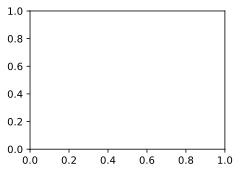

In [46]:

# =====================================================================
# 5. 主程序入口（使用 d2l 香蕉数据集模拟测试）
# =====================================================================
# A. 设置设备与加载 d2l 香蕉数据集
device = d2l.try_gpu()
batch_size = 1  # 当前极简架构以 batch_size=1 演示
train_iter, val_iter = d2l.load_data_bananas(batch_size)

# B. 初始化 Faster R-CNN 模型
net = FasterRCNN(num_classes=1)  # 香蕉数据集只有 1 类

# C. 开始训练 (训练 5 个 Epoch 演示)
print("开始训练...")
train_faster_rcnn(net, train_iter, num_epochs=5, device=device, lr=0.005)

In [ ]:
# D. 预测测试与绘图
print("开始预测测试...")
# 取 Validation 集中的第一张图片测试
for X, Y in val_iter:
    img_tensor = X[0]  # [3, 256, 256]
    boxes, labels, scores = predict(net, img_tensor, device, threshold=0.4)
    
    # 使用 d2l 工具绘制图片与预测框
    # 将 Tensor 转回 PIL 图像维度 (H, W, C) 并反归一化
    img = img_tensor.permute(1, 2, 0).numpy()
    fig = d2l.plt.imshow(img)
    
    if len(boxes) > 0:
        # 乘以图像尺寸 256 将 0~1 归一化坐标转换为绝对像素坐标
        h, w = img.shape[:2]
        scale = torch.tensor([w, h, w, h])
        d2l.show_bboxes(fig.axes, boxes * scale, labels=scores.numpy(), colors=['r'])
    
    d2l.plt.show()
    break

## Mask R-CNN

如果在训练集中还标注了每个目标在图像上的像素级位置，那么*Mask R-CNN* :cite:`He.Gkioxari.Dollar.ea.2017`能够有效地利用这些详尽的标注信息进一步提升目标检测的精度。

![Mask R-CNN 模型](../img/mask-rcnn.svg)
:label:`fig_mask_r-cnn`

如 :numref:`fig_mask_r-cnn`所示，Mask R-CNN是基于Faster R-CNN修改而来的。
具体来说，Mask R-CNN将兴趣区域汇聚层替换为了
*兴趣区域对齐*层，使用*双线性插值*（bilinear interpolation）来保留特征图上的空间信息，从而更适于像素级预测。
兴趣区域对齐层的输出包含了所有与兴趣区域的形状相同的特征图。
它们不仅被用于预测每个兴趣区域的类别和边界框，还通过额外的全卷积网络预测目标的像素级位置。
本章的后续章节将更详细地介绍如何使用全卷积网络预测图像中像素级的语义。


### RoIAlign 详解

**RoIAlign**（Region of Interest Align）是 Mask R-CNN 论文中提出的一种特征提取/池化算法，旨在替代 Faster R-CNN 中的 **RoIPool**。它彻底解决了 RoIPool 在特征提取过程中由于“强行取整（Quantization）”导致的**像素错位问题**，为实例分割（Mask Segmentation）与高精度目标检测提供了精确的像素级对齐（Pixel-level Alignment）。

---

### 1. 为什么需要 RoIAlign？（解决了什么痛点）

#### RoIPool 的痛点：两次量化误差

在传统 Faster R-CNN 使用 RoIPool 时，候选框（RoI）从原图坐标映射到特征图，再划分 Pooling 网格的过程中，经历了**两次强制取整**：

1. **原图到特征图映射的取整**：
* 假设原图候选框大小为 $128 \times 128$，Backbone 的下采样倍率（Stride）为 16。
* 映射到特征图的理论尺寸应为 $128 / 16 = 8.0$。但如果原图候选框大小是 $143 \times 143$，理论尺寸就是 $143 / 16 = 8.9375$。
* RoIPool 做法：直接 `floor` 取整为 $8$。此时在特征图上产生了 $0.9375$ 的偏差，映射回原图就是 **$0.9375 \times 16 \approx 15$ 个像素的偏差**。


2. **划分 Pooling 网格时的取整**：
* 假设要 Pooling 到固定尺寸 $7 \times 7$（划分成 $7 \times 7$ 个 Bin）。
* 特征图上的 $8 \times 8$ 区域划分成 7 份，每个 Bin 宽/高为 $8 / 7 \approx 1.14$。
* RoIPool 做法：再次强制取整（有的 Bin 占 1 个像素，有的占 2 个像素）。



**后果**：这种像素级的微小偏差在**目标检测**（只关心框位置）中尚可接受，但对于**实例分割（Mask 预测）**或**人体关键点估计**这种像素级精度的任务，会导致提取出的 Mask 边缘模糊、错位或变形。

---

### 2. RoIAlign 的核心设计思想

RoIAlign 的核心原则是：**取消所有取整过程，全流程保持浮点数坐标，通过“双线性插值”计算浮点点上的响应值。**

* **0 量化误差**：候选框映射到特征图后，尺寸保持浮点数（如 $8.9375 \times 8.9375$）。
* **连续网格划分**：将其均匀划分为 $k \times k$（如 $7 \times 7$）个 Bin，每个 Bin 的边界也是浮点数（如宽 $8.9375 / 7 = 1.2768$）。
* **采样点与插值**：在每个 Bin 内部放置固定数量的**采样点**（ Sampling Points，论文默认每 Bin 放 4 个点）。使用**双线性插值**根据四周 4 个真实像素节点计算这 4 个采样点的特征值，最后取 Max 或 Average 作为该 Bin 的特征。

---

### 3. RoIAlign 的详细计算流程

假设我们要将一个浮点数 RoI 提取为 $k \times k$（如 $7 \times 7$）大小的特征图：

```
[特征图 (离散网格)]
 ┌───┬───┬───┐
 │ • │ • │ • │  <-- 四周 4 个离散像素点 (Q11, Q21, Q12, Q22)
 ├───┼───┼───┤
 │   │ x │   │  <-- 浮点采样点 (x, y)，通过双线性插值求值
 ├───┼───┼───┤
 │ • │ • │ • │
 └───┴───┴───┴

```

1. **Step 1：浮点映射**
将原图 RoI 坐标 $[x_1, y_1, x_2, y_2]$ 直接除以 Stride（如 16），得到特征图上的浮点区域，全程不做 `round` 或 `floor`。
2. **Step 2：均匀分割 Bin**
将该浮点区域划分成 $k \times k$ 个网格（Bin），每个 Bin 的宽高同样为浮点数。
3. **Step 3：确定采样点（Sampling Points）**
在每一个 Bin 内部均匀确定 $N$ 个采样点（例如 $N=4$，分别位于 Bin 的 $1/4$ 和 $3/4$ 纵横位置）。
4. **Step 4：双线性插值**
每个采样点的坐标都是浮点数 $(x, y)$。利用该点四周最近的 4 个真实整数网格节点响应值 $f(Q_{11}), f(Q_{21}), f(Q_{12}), f(Q_{22})$，计算权值并进行插值得到采样点的值：

$$f(x, y) = \sum_{i,j} w_{ij} \cdot f(Q_{ij})$$


5. **Step 5：池化聚合（Max/Average Pooling）**
对每个 Bin 内算出的 4 个采样点特征值取平均（Average Pooling）或最大值（Max Pooling），作为该 Bin 的最终特征输出。

---

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def roi_align_forward_single(
    feature_map, roi, output_size=(7, 7), spatial_scale=1.0 / 16.0, sampling_ratio=2
):
  """单张特征图与单候选框的极简 RoIAlign 实现

  feature_map: [C, H, W] 离散特征图
  roi: [4] 归一化/绝对坐标候选框 [x1, y1, x2, y2]
  output_size: 输出特征维度 (out_h, out_w)
  spatial_scale: 下采样倍率 (例如 1/16)
  sampling_ratio: 每个 Bin 的采样点数 (如 2 代表 2x2=4 个采样点)
  """
  C, H, W = feature_map.shape
  out_h, out_w = output_size

  # 1. 浮点映射到特征图 (不做取整)
  x1 = roi[0] * spatial_scale
  y1 = roi[1] * spatial_scale
  x2 = roi[2] * spatial_scale
  y2 = roi[3] * spatial_scale

  # 计算浮点 RoI 宽高
  roi_w = max(x2 - x1, 1.0e-3)
  roi_h = max(y2 - y1, 1.0e-3)

  # 每个 Bin 的浮点步长
  bin_size_w = roi_w / out_w
  bin_size_h = roi_h / out_h

  # 初始化输出张量 [C, out_h, out_w]
  output = torch.zeros((C, out_h, out_w), device=feature_map.device)

  # 2. 遍历每个 Bin (i, j)
  for ph in range(out_h):
    for pw in range(out_w):
      # 当前 Bin 在特征图上的浮点起始与终止边界
      bin_x1 = x1 + pw * bin_size_w
      bin_y1 = y1 + ph * bin_size_h

      # 采样点网格定义 (如 2x2 个采样点)
      n_sample_y = sampling_ratio
      n_sample_x = sampling_ratio

      bin_acc = torch.zeros(C, device=feature_map.device)

      for iy in range(n_sample_y):
        # 采样点的浮点 y 坐标 (位于 1/4, 3/4 等均匀位置)
        y = bin_y1 + (iy + 0.5) * bin_size_h / n_sample_y
        for ix in range(n_sample_x):
          # 采样点的浮点 x 坐标
          x = bin_x1 + (ix + 0.5) * bin_size_w / n_sample_x

          # 3. 对采样点 (x, y) 执行双线性插值
          val = bilinear_interpolate(feature_map, x, y)
          bin_acc += val

      # 4. 取平均池化 (Average Pooling)
      output[:, ph, pw] = bin_acc / (n_sample_y * n_sample_x)

  return output


def bilinear_interpolate(feature_map, x, y):
  """计算多通道特征图上浮点点 (x, y) 的双线性插值"""
  C, H, W = feature_map.shape

  # 边界保护
  if x < -0.5 or x > W - 0.5 or y < -0.5 or y > H - 0.5:
    return torch.zeros(C, device=feature_map.device)

  x = max(0.0, min(float(x), W - 1.001))
  y = max(0.0, min(float(y), H - 1.001))

  x1 = int(x)
  y1 = int(y)
  x2 = x1 + 1
  y2 = y1 + 1

  dx = x - x1
  dy = y - y1

  q11 = feature_map[:, y1, x1]
  q21 = feature_map[:, y1, x2]
  q12 = feature_map[:, y2, x1]
  q22 = feature_map[:, y2, x2]

  w11 = (1 - dx) * (1 - dy)
  w21 = dx * (1 - dy)
  w12 = (1 - dx) * dy
  w22 = dx * dy

  return w11 * q11 + w21 * q21 + w12 * q12 + w22 * q22


In [ ]:

# =====================================================================
# 🧪 测试手写 RoIAlign 与 torchvision 官方实现一致性
# =====================================================================

from torchvision.ops import roi_align as tv_roi_align

# 1. 模拟特征图 [1, 256, 16, 16]
feat = torch.randn(1, 256, 16, 16)
# 模拟原图上的候选框 [x1, y1, x2, y2]
roi_box = torch.tensor([[10.5, 12.3, 150.8, 200.2]])
rois_tv = torch.cat([torch.zeros(1, 1), roi_box], dim=1)

# 2. 调用手写 RoIAlign
custom_out = roi_align_forward_single(
    feat[0],
    roi_box[0],
    output_size=(7, 7),
    spatial_scale=1.0 / 16.0,
    sampling_ratio=2,
)

# 3. 调用 torchvision 官方 RoIAlign
official_out = tv_roi_align(
    feat,
    rois_tv,
    output_size=(7, 7),
    spatial_scale=1.0 / 16.0,
    sampling_ratio=2,
)[0]

# 4. 比对误差
diff = torch.abs(custom_out - official_out).max().item()
print("===== RoIAlign 正确性验证 =====")
print(f"手写实现与 Torchvision 官方 API 最大绝对数值误差: {diff:.6e}")

In [ ]:

import math
import random
import d2l.torch as d2l
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import roi_align

# =====================================================================
# 1. 基础网络组件 (Backbone, RPN, MaskHead, MaskRCNN)
# =====================================================================
class Backbone(nn.Module):

  def __init__(self, in_ch=3, out_ch=256):
    super().__init__()
    # 16倍下采样: 256x256 -> 16x16
    self.net = nn.Sequential(
        *[
            nn.Sequential(
                nn.Conv2d(
                    in_ch if i == 0 else out_ch,
                    out_ch,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                ),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            )
            for i in range(4)
        ]
    )

  def forward(self, x):
    return self.net(x)


class RPN(nn.Module):

  def __init__(self, in_ch=256, num_anchors=5, post_nms_top_n=300):
    super().__init__()
    self.post_nms_top_n = post_nms_top_n
    self.conv = nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1)
    self.cls = nn.Conv2d(in_ch, num_anchors * 2, kernel_size=1)
    self.reg = nn.Conv2d(in_ch, num_anchors * 4, kernel_size=1)

  def forward(self, feat, anchors):
    x = F.relu(self.conv(feat))
    cls_preds = self.cls(x).permute(0, 2, 3, 1).reshape(-1, 2)
    reg_preds = self.reg(x).permute(0, 2, 3, 1).reshape(-1, 4)

    scores = F.softmax(cls_preds, dim=-1)[:, 1]
    proposals = d2l.offset_inverse(anchors.squeeze(0), reg_preds).clamp(
        0.0, 1.0
    )

    keep = d2l.nms(proposals, scores, iou_threshold=0.7)[: self.post_nms_top_n]
    return proposals[keep], scores[keep], cls_preds, reg_preds


class MaskHead(nn.Module):

  def __init__(self, in_ch=256, num_classes=1):
    super().__init__()
    self.convs = nn.Sequential(
        nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1),
        nn.ReLU(),
    )
    # 2x2 反卷积上采样: 14x14 -> 28x28
    self.deconv = nn.ConvTranspose2d(in_ch, in_ch, kernel_size=2, stride=2)
    self.predictor = nn.Conv2d(in_ch, num_classes + 1, kernel_size=1)

  def forward(self, roi_feats_14x14):
    x = self.convs(roi_feats_14x14)
    x = F.relu(self.deconv(x))
    return self.predictor(x)  # [K, num_classes + 1, 28, 28]


class MaskRCNN(nn.Module):

  def __init__(
      self, num_classes=1, sizes=[0.2, 0.5, 0.8], ratios=[1, 2, 0.5]
  ):
    super().__init__()
    self.sizes, self.ratios = sizes, ratios
    num_anchors = len(sizes) + len(ratios) - 1

    self.backbone = Backbone(out_ch=256)
    self.rpn = RPN(in_ch=256, num_anchors=num_anchors)

    # 分类与 BBox 回归头
    self.fc = nn.Linear(256 * 7 * 7, 256)
    self.cls_head = nn.Linear(256, num_classes + 1)
    self.bbox_head = nn.Linear(256, (num_classes + 1) * 4)

    # Mask 分割头
    self.mask_head = MaskHead(in_ch=256, num_classes=num_classes)

  def forward(self, x):
    B, _, H, W = x.shape
    feat = self.backbone(x)
    anchors = d2l.multibox_prior(feat, sizes=self.sizes, ratios=self.ratios)

    # 1. RPN 提取 Proposals
    proposals, scores, rpn_cls, rpn_reg = self.rpn(feat, anchors)

    # 2. RoI Align 输入格式转换 [batch_idx, x1, y1, x2, y2]
    rois = torch.cat(
        [
            torch.zeros((len(proposals), 1), device=x.device),
            proposals * torch.tensor([W, H, W, H], device=x.device),
        ],
        dim=1,
    )

    # 3.1 分类与框回归 (7x7 切片)
    roi_feats_7x7 = roi_align(
        feat, rois, output_size=(7, 7), spatial_scale=1 / 16.0
    )
    flat_feats = F.relu(self.fc(roi_feats_7x7.view(len(proposals), -1)))
    roi_cls = self.cls_head(flat_feats)
    roi_reg = self.bbox_head(flat_feats)

    # 3.2 掩码分割 (14x14 切片 -> 28x28 Mask 输出)
    roi_feats_14x14 = roi_align(
        feat, rois, output_size=(14, 14), spatial_scale=1 / 16.0
    )
    mask_logits = self.mask_head(roi_feats_14x14)

    return (
        anchors,
        rpn_cls,
        rpn_reg,
        roi_cls,
        roi_reg,
        mask_logits,
        proposals,
        rois,
    )

Mask R-CNN 的总损失公式为：$$L_{\text{total}} = L_{\text{cls\_rpn}} + L_{\text{box\_rpn}} + L_{\text{cls\_roi}} + L_{\text{box\_roi}} + L_{\text{mask}}$$其中，Mask 损失仅在正样本（Positive RoIs）上计算，代码演示如下：

In [ ]:
# =====================================================================
# 2. 损失函数计算
# =====================================================================
cls_loss_fn = nn.CrossEntropyLoss(reduction="none")
bbox_loss_fn = nn.L1Loss(reduction="none")


def calc_rpn_loss(rpn_cls, rpn_labels, rpn_reg, bbox_labels, bbox_masks):
  """计算 RPN 分类与边界框损失"""
  cls_l = cls_loss_fn(rpn_cls, rpn_labels).mean()
  reg_l = bbox_loss_fn(
      rpn_reg * bbox_masks, bbox_labels * bbox_masks
  ).mean()
  return cls_l + reg_l


def calc_mask_loss(
    mask_logits, proposals, gt_boxes, gt_masks, img_shape=(256, 256)
):
  """计算正样本 RoI 的二值交叉熵 Mask Loss"""
  if len(proposals) == 0 or len(gt_boxes) == 0:
    return torch.tensor(0.0, device=mask_logits.device)

  # 计算 Proposals 与 GT 框的 IoU，选出重叠度 > 0.5 的正样本 RoI
  ious = d2l.box_iou(proposals, gt_boxes)
  max_ious, max_idx = ious.max(dim=1)
  pos_inds = torch.where(max_ious >= 0.5)[0]

  if len(pos_inds) == 0:
    return torch.tensor(0.0, device=mask_logits.device)

  # 提取正样本对应的 logits (取 class=1 通道) 与 GT 实例掩码
  pos_logits = mask_logits[pos_inds, 1]  # [N_pos, 28, 28]
  pos_proposals = proposals[pos_inds]  # [N_pos, 4]
  matched_gt_masks = gt_masks[max_idx[pos_inds]]  # [N_pos, H, W]

  # 将 GT 全图 Mask 作 RoI Crop 并 resize 到 28x28 作为训练 Target
  H, W = img_shape
  rois = torch.cat(
      [
          torch.zeros((len(pos_proposals), 1), device=proposals.device),
          pos_proposals * torch.tensor([W, H, W, H], device=proposals.device),
      ],
      dim=1,
  )

  # 利用 roi_align 快速裁切并缩放 GT Mask 至 28x28 分辨率
  target_masks = roi_align(
      matched_gt_masks.unsqueeze(1).float(),
      rois,
      output_size=(28, 28),
      spatial_scale=1.0,
  ).squeeze(1)

  target_masks = (target_masks >= 0.5).float()
  return F.binary_cross_entropy_with_logits(pos_logits, target_masks)

In [ ]:

# =====================================================================
# 3. 合成数据生成器 (自动生成 Circle 图形、BBox 及对应像素级 Mask)
# =====================================================================
def generate_synthetic_data(batch_size=1, img_size=256):
  """生成单张包含随机圆形目标的图像、归一化 BBox 标注以及全图 Mask"""
  X = torch.zeros((batch_size, 3, img_size, img_size))
  gt_boxes = []
  gt_masks = []

  # 生成随机圆心与半径
  cx, cy = random.randint(60, 190), random.randint(60, 190)
  r = random.randint(30, 50)

  y, x = torch.meshgrid(
      torch.arange(img_size), torch.arange(img_size), indexing="ij"
  )
  mask = ((x - cx) ** 2 + (y - cy) ** 2) <= r**2

  # 图像充填像素
  X[0, 0, mask] = 0.8  # R 通道高亮
  X[0, 1, mask] = 0.2
  X[0, 2, mask] = 0.2

  # 构造 BBox (xmin, ymin, xmax, ymax) 归一化格式
  bbox = torch.tensor([[
      max(0, cx - r) / img_size,
      max(0, cy - r) / img_size,
      min(img_size, cx + r) / img_size,
      min(img_size, cy + r) / img_size,
  ]])

  # 对应的 multibox_target 格式 [class_id, xmin, ymin, xmax, ymax] (1表示圆形类)
  Y = torch.cat([torch.tensor([[0.0]]), bbox], dim=1).unsqueeze(0)

  return X, Y, bbox, mask.unsqueeze(0)

In [ ]:

# =====================================================================
# 4. 完整训练过程
# =====================================================================
def train_mask_rcnn(net, num_epochs=15, lr=0.005, device="cuda"):
  net = net.to(device)
  optimizer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9)

  print(f"开始在 {device} 上训练 Mask R-CNN...")
  net.train()

  for epoch in range(num_epochs):
    # 生成 1 样本进行迭代
    X, Y, bbox, mask = generate_synthetic_data()
    X, Y, bbox, mask = (
        X.to(device),
        Y.to(device),
        bbox.to(device),
        mask.to(device),
    )

    optimizer.zero_grad()

    # 1. 前向传播
    anchors, rpn_cls, rpn_reg, roi_cls, roi_reg, mask_logits, proposals, _ = (
        net(X)
    )

    # 2. 为 RPN Anchors 分配 Ground Truth 标签
    bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y)

    # 3. 计算 Losses
    l_rpn = calc_rpn_loss(rpn_cls, cls_labels, rpn_reg, bbox_labels, bbox_masks)
    l_mask = calc_mask_loss(
        mask_logits, proposals, bbox, mask, img_shape=(256, 256)
    )

    total_loss = l_rpn + l_mask * 2.0  # 给 Mask Loss 赋予适当权重
    total_loss.backward()
    optimizer.step()

    if (epoch + 1) % 3 == 0:
      print(
          f"Epoch [{epoch+1}/{num_epochs}] | Total Loss: {total_loss.item():.4f}"
          f" | RPN Loss: {l_rpn.item():.4f} | Mask Loss:"
          f" {l_mask.item():.4f}"
      )

In [ ]:

# =====================================================================
# 5. 预测与 Mask 可视化叠加
# =====================================================================
def predict_and_visualize(net, device):
  net.eval()
  X, Y, gt_bbox, gt_mask = generate_synthetic_data()
  X_dev = X.to(device)

  with torch.no_grad():
    anchors, rpn_cls, rpn_reg, roi_cls, roi_reg, mask_logits, proposals, _ = (
        net(X_dev)
    )

    # 1. 提取二分类前景得分高于 0.5 的 Proposals
    scores = F.softmax(rpn_cls, dim=-1)[:, 1]
    keep = scores >= 0.5

    if keep.sum() == 0:
      print("未发现高置信度目标")
      return

    pred_boxes = proposals[keep]
    pred_scores = scores[keep]
    pred_masks = torch.sigmoid(mask_logits[keep, 1, :, :])  # [N_keep, 28, 28]

    # NMS 筛选
    final_keep = d2l.nms(pred_boxes, pred_scores, iou_threshold=0.5)[:1]
    best_box = pred_boxes[final_keep]
    best_score = pred_scores[final_keep]
    best_mask_28x28 = pred_masks[final_keep].squeeze(0)  # [28, 28]

    # 2. 将 28x28 Mask 映射放回到 BBox 对应的全图区域中
    img_h, img_w = 256, 256
    box_pixel = (best_box[0] * torch.tensor([img_w, img_h, img_w, img_h])).int()
    xmin, ymin, xmax, ymax = box_pixel.tolist()
    bw, bh = max(1, xmax - xmin), max(1, ymax - ymin)

    # 将 28x28 特征 Mask 插值到真实的 Box 宽高像素尺寸
    resized_mask = F.interpolate(
        best_mask_28x28.unsqueeze(0).unsqueeze(0),
        size=(bh, bw),
        mode="bilinear",
        align_corners=False,
    ).squeeze()

    binary_mask = (resized_mask > 0.5).cpu().numpy()

    # 3. 在原图上画 Mask 覆盖层 (绿层) 和检测框
    img_np = X[0].permute(1, 2, 0).numpy().copy()
    overlay = img_np.copy()

    # 将检测到的 Mask 区域渲染为绿色半透明遮罩
    overlay[ymin:ymax, xmin:xmax][binary_mask] = [0.0, 1.0, 0.0]
    img_masked = 0.6 * img_np + 0.4 * overlay

    # 显示结果图
    fig = d2l.plt.imshow(img_masked)
    scale = torch.tensor([img_w, img_h, img_w, img_h])
    d2l.show_bboxes(
        fig.axes,
        best_box * scale,
        labels=[f"Score: {best_score.item():.2f}"],
        colors=["r"],
    )
    d2l.plt.title("Mask R-CNN Prediction Result")
    d2l.plt.show()


In [ ]:
# =====================================================================
# 主程序入口
# =====================================================================
device = d2l.try_gpu()

# 1. 初始化模型
net = MaskRCNN(num_classes=1)

# 2. 训练模型 (合成数据集上快速拟合 15 次)
train_mask_rcnn(net, num_epochs=15, lr=0.01, device=device)

# 3. 预测并绘制分割 Mask + 边界框
print("\n执行 Mask R-CNN 测试与可视化...")
predict_and_visualize(net, device)


## 小结

* R-CNN对图像选取若干提议区域，使用卷积神经网络对每个提议区域执行前向传播以抽取其特征，然后再用这些特征来预测提议区域的类别和边界框。
* Fast R-CNN对R-CNN的一个主要改进：只对整个图像做卷积神经网络的前向传播。它还引入了兴趣区域汇聚层，从而为具有不同形状的兴趣区域抽取相同形状的特征。
* Faster R-CNN将Fast R-CNN中使用的选择性搜索替换为参与训练的区域提议网络，这样后者可以在减少提议区域数量的情况下仍保证目标检测的精度。
* Mask R-CNN在Faster R-CNN的基础上引入了一个全卷积网络，从而借助目标的像素级位置进一步提升目标检测的精度。

## 练习

1. 我们能否将目标检测视为回归问题（例如预测边界框和类别的概率）？可以参考YOLO模型 :cite:`Redmon.Divvala.Girshick.ea.2016`的设计。
1. 将单发多框检测与本节介绍的方法进行比较。他们的主要区别是什么？可以参考 :cite:`Zhao.Zheng.Xu.ea.2019`中的图2。